# Encontro 3 — Validar a solução e comunicar

**De onde viemos:** o Encontro 2 fechou a RCA da Serra-02 (causa-raiz de **processo**
no turno da Noite). Encontrar a causa não é o fim — falta **provar que a correção
funciona** e **comunicar** o resultado para quem decide. É o que separa "achei a causa"
de "resolvi o problema".

**Você vai praticar:**
1. **Causa-raiz vs sintoma** — distinguir workaround de solução permanente.
2. **Provar eficácia** — declarar a métrica que deve se mover e ler o antes/depois.
3. **Comunicar** — estrutura de PIR e tradução técnico → negócio (refugo/retrabalho em R$).
4. **Mock interview** — banco de perguntas reais (com fontes) para a vaga de analista.

## Da fábrica para a TI (e para o laboratório de ensaios)

| Chão de fábrica | TI / ITIL 4 | → Laboratório de ensaios |
|---|---|---|
| Recalibrar a serra todo turno para seguir cortando | **Workaround** (alívio, não cura) | Recalibrar/repetir o ensaio a cada lote para liberar o resultado |
| Padrão de calibração + manutenção preventiva | **Solução permanente** | Validação/calibração de método padronizada |
| Causa conhecida + contorno documentado | **Known Error** na KEDB | Known Error do método/instrumento documentado |
| Queda do refugo semanal após a correção | **Métrica de eficácia** | Queda do **TAT** e da **taxa de reanálise** |
| Refugo e retrabalho evitados (R$) | **Impacto de negócio** | Amostras reanalisadas evitadas (custo + atraso no laudo) |

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Para INTERATIVO na sessão ao vivo: pio.renderers.default = "notebook"
pio.renderers.default = "png"
pio.templates.default = "plotly_white"

df = pd.read_csv("../data/ocorrencias.csv", parse_dates=["aberto_em", "resolvido_em"])
serra = df[df.maquina == "Serra-02"].copy()

# SETOR_ALVO parametriza SÓ o enquadramento do mock (perguntas e fontes seguem iguais).
SETOR_ALVO = "laboratorios-de-ensaios"
SETOR_LABEL = "laboratório de ensaios analíticos / life sciences"
METRICA_SETOR = "TAT (turnaround time) das amostras e/ou taxa de reanálise (mapeia para MTTR/SLA)"
print(f"Setor-alvo do mock: {SETOR_ALVO}  ({SETOR_LABEL})")

Setor-alvo do mock: laboratorios-de-ensaios  (laboratório de ensaios analíticos / life sciences)


## 1. Causa-raiz vs sintoma — workaround não é solução

Diante do refugo da Serra-02, há duas respostas:

| Resposta | O que é | Em ITIL |
|---|---|---|
| **Recalibrar a serra a cada turno** e seguir cortando | Trata o **sintoma**; o desvio volta no turno seguinte | **Workaround** |
| **Padrão de calibração por turno + checagem dimensional + manutenção preventiva** | Ataca a **causa-raiz de processo** | **Solução permanente** (Known Error resolvido) |

O workaround é legítimo **enquanto** a solução permanente não está implantada — e deve
ser **documentado** (na fábrica: instrução de trabalho; em TI: KEDB). Mas se a operação
parar no workaround, o problema **nunca fecha**: o refugo continua, só não surpreende.

> Pergunta-chave para o aluno: *"O que muda no gráfico se aplicarmos só o workaround
> vs a solução permanente?"* — o workaround **estabiliza**; a solução permanente **derruba**.

## 2. Provar eficácia — qual métrica deve se mover?

Uma correção sem métrica é fé, não engenharia. **Declare antes** o que deve mudar:

> **Métrica de eficácia:** volume semanal de ocorrências `corte-fora-medida` na Serra-02.
> **Meta:** voltar ao patamar do baseline (~3/sem) ou abaixo, e **manter** por ≥4 semanas.

> **No setor-alvo (laboratório de ensaios):** a métrica equivalente é o **TAT (turnaround
> time)** das amostras e/ou a **taxa de reanálise** — exatamente o papel de MTTR/SLA. Mesma
> lógica: declare alvo e janela de sustentação antes de afirmar que a correção funcionou.

Primeiro, o "antes" — a série **real** dos 90 dias (a rampa que motivou o registro):

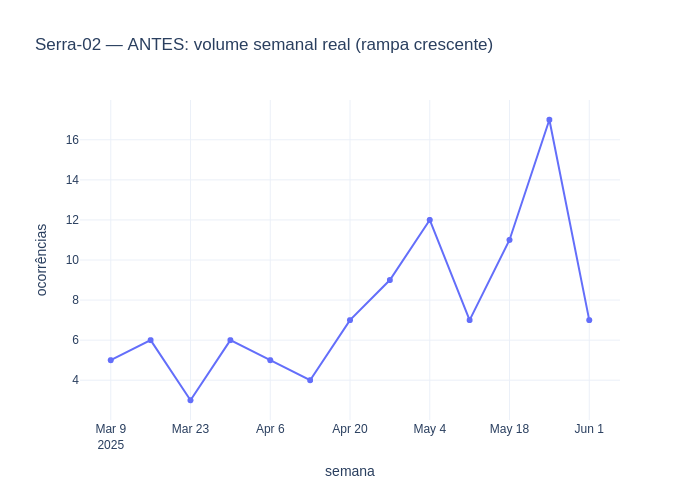

Baseline: 5.0/sem  ->  Últimas 4 semanas: 10.5/sem


In [2]:
antes = serra.set_index("aberto_em").resample("W").size()
antes_df = antes.reset_index(name="ocorrencias")
fig = px.line(antes_df, x="aberto_em", y="ocorrencias", markers=True,
              title="Serra-02 — ANTES: volume semanal real (rampa crescente)")
fig.update_layout(xaxis_title="semana", yaxis_title="ocorrências")
fig.show()
print(f"Baseline: {antes.iloc[:4].mean():.1f}/sem  ->  Últimas 4 semanas: {antes.iloc[-4:].mean():.1f}/sem")

### ⚠️ Honestidade pedagógica sobre o "depois" (ADR-05)

A correção **não aconteceu** dentro do log de 90 dias — seria desonesto mostrar uma
queda real que não existe nos dados. Então o "depois" é uma **série ilustrativa,
gerada de forma determinística e rotulada como tal**: aplicamos a redução *esperada*
da intervenção sobre a projeção das próximas semanas.

O hábito que isso ensina: **separe o que você mediu do que você projeta.** Em uma
entrevista (ou para a liderança), apresentar projeção como medição destrói credibilidade.
Aqui o gráfico deixa explícito o ponto da intervenção e marca o trecho como *ilustrativo*.

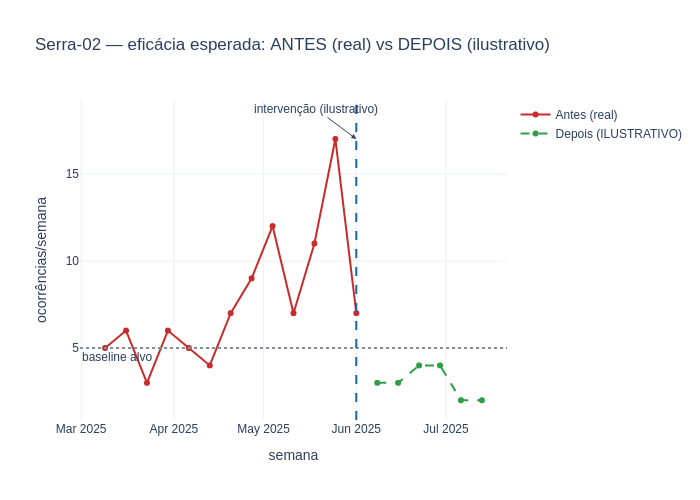

In [3]:
def projecao_pos_correcao(volume_semanal_real, reducao=0.7, horizonte=6, seed=42):
    """Série ILUSTRATIVA do volume esperado após a correção (rotular no gráfico)."""
    import numpy as np
    rng = np.random.default_rng(seed)
    base = float(volume_semanal_real.tail(4).mean())
    return [max(0, round(base * (1 - reducao) + rng.normal(0, 0.5))) for _ in range(horizonte)]


horizonte = 6
depois_vals = projecao_pos_correcao(antes, reducao=0.7, horizonte=horizonte)
semana_corte = antes.index.max()
depois_idx = pd.date_range(semana_corte + pd.Timedelta(weeks=1), periods=horizonte, freq="W")

fig = go.Figure()
fig.add_trace(go.Scatter(x=antes.index, y=antes.values, mode="lines+markers",
                         name="Antes (real)", line=dict(color="#c92a2a")))
fig.add_trace(go.Scatter(x=depois_idx, y=depois_vals, mode="lines+markers",
                         name="Depois (ILUSTRATIVO)", line=dict(color="#2f9e44", dash="dash")))
fig.add_hline(y=antes.iloc[:4].mean(), line_dash="dot", line_color="#868e96",
              annotation_text="baseline alvo", annotation_position="bottom left")
fig.add_vline(x=semana_corte, line_dash="dash", line_color="#1864ab")
fig.add_annotation(x=semana_corte, y=max(antes.values), text="intervenção (ilustrativo)",
                   showarrow=True, arrowhead=2, ax=-40, ay=-30)
fig.update_layout(title="Serra-02 — eficácia esperada: ANTES (real) vs DEPOIS (ilustrativo)",
                  xaxis_title="semana", yaxis_title="ocorrências/semana")
fig.show()

**Leia o gráfico:** a linha vermelha é **medição** (o que aconteceu); a verde
tracejada é **projeção rotulada** (o que esperamos que aconteça se a causa-raiz for
corrigida). O critério de sucesso é objetivo: a verde precisa **cruzar para baixo do
baseline e ficar lá**. Sem isso, a correção não está provada — só implantada.

## 3. Comunicar — do dado técnico ao impacto de negócio

A liderança não decide por "ocorrências/semana"; decide por **R$**. Traduza a métrica
técnica em **refugo e retrabalho evitados**. Suponha um custo médio de refugo por peça.

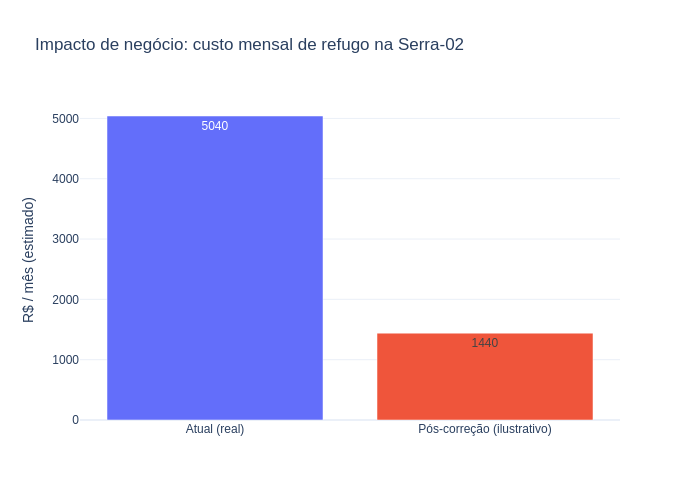

Economia mensal estimada: R$ 3,600  (cenário ilustrativo)


In [4]:
CUSTO_REFUGO_PECA = 120.0  # R$ por peça refugada (premissa do exercício)

ocorr_mes_antes = antes.iloc[-4:].mean() * 4        # ~mês no pior patamar
ocorr_mes_depois = (sum(depois_vals) / len(depois_vals)) * 4  # ~mês projetado
custo = pd.DataFrame({
    "cenário": ["Atual (real)", "Pós-correção (ilustrativo)"],
    "custo_mensal_R$": [ocorr_mes_antes * CUSTO_REFUGO_PECA,
                        ocorr_mes_depois * CUSTO_REFUGO_PECA],
})
fig = px.bar(custo, x="cenário", y="custo_mensal_R$", text_auto=".0f", color="cenário",
             title="Impacto de negócio: custo mensal de refugo na Serra-02")
fig.update_layout(showlegend=False, xaxis_title="", yaxis_title="R$ / mês (estimado)")
fig.show()
economia = (ocorr_mes_antes - ocorr_mes_depois) * CUSTO_REFUGO_PECA
print(f"Economia mensal estimada: R$ {economia:,.0f}  (cenário ilustrativo)")

### Estrutura de PIR (Post-Incident Review / Revisão pós-problema)

Use este esqueleto para comunicar o fechamento — funciona igual em TI:

1. **Resumo** — o problema em 2 linhas (Serra-02, refugo crescente por corte fora de medida).
2. **Impacto** — quanto custou (refugo/retrabalho em R$, peças perdidas, atraso de entrega).
3. **Linha do tempo** — quando começou a degradar, quando foi detectado, quando foi corrigido.
4. **Causa-raiz** — de processo (sem padrão de calibração/conferência por turno, agravado à noite).
5. **Ação corretiva** — padrão de calibração + checagem dimensional + reforço no 3º turno.
6. **Eficácia** — métrica declarada e o antes/depois (com o "depois" rotulado como projeção).
7. **Lições / prevenção** — onde mais esse padrão pode aparecer (outras serras, outros turnos).

> Tradução técnico → negócio: *"Reduzimos o refugo da Serra-02 de ~R$ X/mês para ~R$ Y/mês
> padronizando a calibração por turno"* diz mais à liderança do que qualquer gráfico de séries.

## 4. Mock interview — banco de perguntas (com fontes)

Perguntas reais de entrevistas para **Problem Analyst / ITIL Problem Management**,
parafraseadas de bancos de perguntas e de um anúncio de vaga real (fontes no `README`/guia).
Responda **em voz alta** usando o método **STAR** (Situação · Tarefa · Ação · Resultado),
puxando exemplos do que você acabou de fazer com a Serra-02 e a Coladeira-01.

> **Enquadramento do setor-alvo (laboratório de ensaios / life sciences):** ao responder,
> **traduza** os exemplos da fábrica para o vocabulário do laboratório — `LIMS`,
> `amostra → resultado`, `ensaio/análise`, `instrumento analítico`, `TAT/SLA`, `reanálise`,
> `rede de laboratórios`. Ex.: a Serra-02 (defeito sistemático) vira *"um método analítico
> que força reanálise sistemática"*; a Coladeira-01 (recorrência sutil) vira *"uma integração
> de instrumento que perde dados ~toda semana"*. As perguntas e fontes são de ITIL/RCA e
> valem para qualquer setor.

**Fundamentos e decisão**
- Quando um conjunto de incidentes deixa de ser "só incidentes" e vira um **problema**? *(interviewquestions.guru)*
- Diferença entre Problem Management **reativo e proativo**. *(hirist)*
- O que é um **workaround** e como ele se relaciona com a solução permanente ao longo do tempo? *(theknowledgeacademy)*
- Um mesmo tipo de chamado se repete toda semana. **O que você faz?** *(skilr; hirist)*

**RCA (comportamentais — STAR)**
- Conte sobre um **problema recorrente** cuja causa-raiz você teve de descobrir. *(yardstick)*
- Conte sobre uma vez em que os outros tratavam só o **sintoma** e você resolveu na **raiz**. *(yardstick)*
- Que **metodologias de RCA** você usa e quando? (5 Porquês, Ishikawa, Kepner-Tregoe) *(itjobswatch; hirist)*

**Validação e comunicação**
- Como você **prova que a correção funcionou**? Qual métrica deve se mover antes/depois? *(PIR; vervecopilot)*
- Como **traduz um achado técnico em impacto de negócio** para a liderança? *(interviewquery)*

> As **respostas-modelo** (com critérios de boa resposta e sinais de alerta) estão no
> **guia do instrutor** — aqui você treina a sua própria resposta primeiro.

## Exercício (sem resposta pronta)

1. Escolha **3 perguntas** do banco acima e escreva sua resposta no formato **STAR**,
   usando a Serra-02 e a Coladeira-01 como matéria-prima.
2. Para a Serra-02, escreva o **PIR completo** (7 itens) como se fosse comunicar à diretoria.
3. Para a pergunta *"como você prova que a correção funcionou?"*, nomeie a métrica, o alvo
   e por quanto tempo ela precisa se manter — e diga **o que você NÃO mediria** (a armadilha
   de apresentar projeção como medição).

> A leitura comentada e as respostas-modelo estão no **guia do instrutor**, não aqui.

In [5]:
# Espaço de trabalho do aluno: rascunhe aqui suas respostas STAR e o PIR.
# Ex.: comparar Serra-02 (tendência+Pareto) vs Coladeira-01 (recorrência) como dois
# "problemas" de naturezas diferentes que você diagnosticou.
respostas = {
    "pergunta_1": "...",
    "pergunta_2": "...",
    "pergunta_3": "...",
}
respostas

{'pergunta_1': '...', 'pergunta_2': '...', 'pergunta_3': '...'}